In [7]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, Iterator, List, Optional, Sequence, Tuple, Union

import numpy as np
import pandas as pd

import xgboost as xgb
import lightgbm as lgb
from lightgbm import LGBMClassifier
import shap

In [8]:
from config import dir_config
compiled_dir = dir_config.data.compiled
processed_dir = dir_config.data.processed

In [9]:

sleep_stage_cols = ['sleep_stage', 'sleep_stage_transition', 'sleep_stage_trans_prop']
apnea_cols = ['apnea_obstructive', 'apnea_central', 'apnea_hypopnea', 'apnea_mixed']
epoch_cols = ['epoch_id', 'epoch_start', 'epoch_end']
subject_col = []
additional_cols = ['ahi', 'oahi', 'arousal_index']

target_type = 'apnea'


# Load data

In [10]:
# get all parquet files in the processed directory
parquet_files = list(Path(processed_dir).glob('*_with_metadata.parquet'))
# read all parquet files into a single dataframe

# remove "agg_data_with_metadata.parquet" from the list of parquet files
parquet_files = [f for f in parquet_files if f.name != "agg_data_with_metadata.parquet"]

# df = pd.concat([pd.read_parquet(parquet_file) for parquet_file in parquet_files], ignore_index=True)

## Chunk in 0.5hr

In [11]:
def create_batched_splits(
    parquet_files: list,
    batch_size: int = 360,
    gap_size: int = 6,
    top_features: list[str] | None = None,
    top_features_lag: int = 5,
    target_type: str = 'apnea',
    target_future_steps: int = 5,
    val_ratio: float = 0.2,
    test_ratio: float = 0.2,
    n_leave_out: int = 5,
    random_seed: int = 2542,
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series, pd.DataFrame, pd.Series, list]:
    """
    Batch parquet files into non-overlapping windows and split into train/val/test sets.

    Args:
        parquet_files:        List of parquet file paths.
        batch_size:           Number of rows per batch.
        gap_size:             Number of rows to skip between batches (to avoid leakage).
        top_features:         Features to create lag features for. None means no lag features.
        top_features_lag:     Number of lag steps to generate for top_features.
        target_type:          Type of target to generate ('apnea' supported).
        target_future_steps:  How many steps ahead the target looks.
        val_ratio:            Fraction of each subject's batches for validation.
        test_ratio:           Fraction of each subject's batches for testing.
        n_leave_out:          Number of subjects to exclude entirely.
        random_seed:          Random seed for reproducibility.

    Returns:
        train_X, train_y, val_X, val_y, test_X, test_y, left_out_subjects
    """
    rng = np.random.default_rng(random_seed)

    batches = _chunk_subjects(
        parquet_files=parquet_files,
        batch_size=batch_size,
        gap_size=gap_size,
        top_features=top_features or [],
        top_features_lag=top_features_lag,
        target_type=target_type,
        target_future_steps=target_future_steps,
    )

    subject_ids = np.array(list(batches.keys()))
    left_out_subjects = rng.choice(subject_ids, size=n_leave_out, replace=False).tolist()
    print(f"Subjects left out: {left_out_subjects}")

    train_batches, val_batches, test_batches = [], [], []

    for subject_id, subject_batches in batches.items():
        if subject_id in left_out_subjects:
            continue

        subject_batches = subject_batches.copy()
        rng.shuffle(subject_batches)

        n = len(subject_batches)
        n_test = round(n * test_ratio)
        n_val = round(n * val_ratio)

        train_batches.extend(subject_batches[: n - n_val - n_test])
        val_batches.extend(subject_batches[n - n_val - n_test : n - n_test])
        test_batches.extend(subject_batches[n - n_test :])

    train_df = pd.concat(train_batches, ignore_index=True)
    val_df = pd.concat(val_batches, ignore_index=True)
    test_df = pd.concat(test_batches, ignore_index=True)

    train_y, train_X = train_df['target'], train_df.drop(columns='target')
    val_y,   val_X   = val_df['target'],   val_df.drop(columns='target')
    test_y,  test_X  = test_df['target'],  test_df.drop(columns='target')

    return train_X, train_y, val_X, val_y, test_X, test_y, left_out_subjects


def _chunk_subjects(
    parquet_files: list,
    batch_size: int,
    gap_size: int,
    top_features: list[str],
    top_features_lag: int,
    target_type: str = 'apnea',
    target_future_steps: int = 5,
) -> dict[str, list[pd.DataFrame]]:
    """
    Read parquet files and chunk each subject's data into non-overlapping batches
    separated by a gap to prevent leakage between splits.

    Args:
        parquet_files:        List of parquet file paths.
        batch_size:           Number of rows per batch.
        gap_size:             Number of rows to skip between consecutive batches.
        top_features:         Features to create lag features for.
        top_features_lag:     Number of lag steps to generate for top_features.
        target_type:          Type of target to generate.
        target_future_steps:  How many steps ahead the target looks.

    Returns:
        Dictionary mapping subject_id -> list of batch DataFrames.
    """
    batches = {}

    for parquet_file in parquet_files:
        df = pd.read_parquet(parquet_file)
        subject_id = Path(parquet_file).stem.split("_")[0]

        subject_batches = []
        for start in range(0, len(df), batch_size + gap_size):
            batch = df.iloc[start : start + batch_size].copy()

            if len(batch) < batch_size:  # drop incomplete trailing batches
                continue

            batch = add_future_target(df=batch, target_type=target_type, future_steps=target_future_steps)
            batch = batch.dropna(subset=['target'])
            batch = add_lag_features(batch, features=top_features, max_lag=top_features_lag)
            batch = remove_feature_columns(batch, target_type)

            subject_batches.append(batch)

        batches[subject_id] = subject_batches

    return batches


def add_future_target(df: pd.DataFrame, target_type: str = 'apnea', future_steps: int = 0) -> pd.DataFrame:
    """
    Add a future target column to the DataFrame by shifting the target columns forward.

    Args:
        df:           Input DataFrame.
        target_type:  Type of target to generate ('apnea' supported).
        future_steps: How many steps ahead the target looks.

    Returns:
        DataFrame with 'target' column added.
    """
    if target_type == 'apnea':
        df['target'] = df[apnea_cols].shift(-future_steps).max(axis=1)
    elif target_type == 'sleep_stage':
        raise NotImplementedError("Future target for sleep stage prediction is not implemented yet.")

    return df


def remove_feature_columns(df: pd.DataFrame, target_type: str) -> pd.DataFrame:
    """
    Drop non-feature columns from the DataFrame, retaining only model inputs and target.

    Args:
        df:          Input DataFrame.
        target_type: Determines which column groups to drop.

    Returns:
        DataFrame with non-feature columns removed.
    """
    if target_type == 'apnea':
        columns_to_drop = sleep_stage_cols + apnea_cols + epoch_cols + subject_col + additional_cols
    elif target_type == 'sleep_stage':
        raise NotImplementedError("Feature column removal for sleep stage prediction is not implemented yet.")

    return df.drop(columns=columns_to_drop)


def add_lag_features(
    df: pd.DataFrame,
    features: list[str] | None = None,
    max_lag: int = 0,
) -> pd.DataFrame:
    """
    Add lag features for specified columns.

    Args:
        df:       Input DataFrame.
        features: List of feature names to create lag features for.
        max_lag:  Maximum number of lag periods to create.

    Returns:
        DataFrame with lag features added.
    """
    if not features or max_lag < 1:
        return df

    df = df.copy()
    for feature in features:
        for lag in range(1, max_lag + 1):
            df[f"{feature}_lag{lag}"] = df[feature].shift(lag)

    # Drop first max_lag rows which have NaN values from the lag shift
    return df.iloc[max_lag:].reset_index(drop=True)

In [12]:
train_X, train_y, val_X, val_y, test_X, test_y, left_out = create_batched_splits(
    parquet_files,
    batch_size=360,
    gap_size=6,
    top_features=None,
    top_features_lag=0,
    target_type='apnea',
    target_future_steps=0,
    val_ratio=0.2,
    test_ratio=0.2,
    n_leave_out=5,
    random_seed=2542,
)

Subjects left out: ['S038', 'S003', 'S009', 'S068', 'S016']


### XGBoost

In [13]:
## xgboost model
# for binary classification
neg = (train_y == 0).sum()
pos = (train_y == 1).sum()

model_xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    scale_pos_weight=neg/pos,  # adjust for class imbalance
    early_stopping_rounds=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=2542,
    eval_metric='aucpr'
)

model_xgb.fit(train_X, train_y, eval_set=[(val_X, val_y)], verbose=True)


[0]	validation_0-aucpr:0.36403
[1]	validation_0-aucpr:0.41412
[2]	validation_0-aucpr:0.42824
[3]	validation_0-aucpr:0.43899
[4]	validation_0-aucpr:0.46825
[5]	validation_0-aucpr:0.47709
[6]	validation_0-aucpr:0.48039
[7]	validation_0-aucpr:0.48636
[8]	validation_0-aucpr:0.49763
[9]	validation_0-aucpr:0.50021
[10]	validation_0-aucpr:0.50265
[11]	validation_0-aucpr:0.50816
[12]	validation_0-aucpr:0.51458
[13]	validation_0-aucpr:0.51902
[14]	validation_0-aucpr:0.52216
[15]	validation_0-aucpr:0.52778
[16]	validation_0-aucpr:0.52896
[17]	validation_0-aucpr:0.53431
[18]	validation_0-aucpr:0.54173
[19]	validation_0-aucpr:0.54581
[20]	validation_0-aucpr:0.54912
[21]	validation_0-aucpr:0.55212
[22]	validation_0-aucpr:0.55499
[23]	validation_0-aucpr:0.55751
[24]	validation_0-aucpr:0.56026
[25]	validation_0-aucpr:0.56189
[26]	validation_0-aucpr:0.56538
[27]	validation_0-aucpr:0.56737
[28]	validation_0-aucpr:0.57015
[29]	validation_0-aucpr:0.57299
[30]	validation_0-aucpr:0.57430
[31]	validation_0-

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=2542, ...)

In [14]:
# imports
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, classification_report, confusion_matrix

def evaluate_model(model, X, y, threshold=0.5):
    y_pred_proba = model.predict_proba(X)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)
    auc_roc = roc_auc_score(y, y_pred_proba)
    auc_pr = average_precision_score(y, y_pred_proba)
    f1 = f1_score(y, y_pred)
    #
    classification = classification_report(y, y_pred)
    confusion = confusion_matrix(y, y_pred)
    return {'auc_roc': auc_roc, 'auc_pr': auc_pr, 'f1': f1, 'classification_report': classification, 'confusion_matrix': confusion}

In [15]:
# Get model evaluation metrics for the train set
print("XGBoost Model Evaluation on Train Set:")
metrics = evaluate_model(model_xgb, train_X, train_y)
print(f"AUC-ROC: {metrics['auc_roc']:.4f}")
print(f"AUC-PR: {metrics['auc_pr']:.4f}")
print(f"F1 Score: {metrics['f1']:.4f}")
print("Classification Report:")
print(metrics['classification_report'])

# Get model evaluation metrics for the validation set
print("XGBoost Model Evaluation on Validation Set:")
metrics = evaluate_model(model_xgb, val_X, val_y)
print(f"AUC-ROC: {metrics['auc_roc']:.4f}")
print(f"AUC-PR: {metrics['auc_pr']:.4f}")
print(f"F1 Score: {metrics['f1']:.4f}")
print("Classification Report:")
print(metrics['classification_report'])

XGBoost Model Evaluation on Train Set:
AUC-ROC: 0.9464
AUC-PR: 0.7341
F1 Score: 0.6012
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.86      0.91    221783
           1       0.45      0.89      0.60     29857

    accuracy                           0.86    251640
   macro avg       0.72      0.87      0.76    251640
weighted avg       0.92      0.86      0.88    251640

XGBoost Model Evaluation on Validation Set:
AUC-ROC: 0.8968
AUC-PR: 0.6336
F1 Score: 0.5471
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.84      0.90     77815
           1       0.42      0.79      0.55     11465

    accuracy                           0.83     89280
   macro avg       0.69      0.81      0.72     89280
weighted avg       0.89      0.83      0.85     89280



In [16]:
from xgboost import plot_importance
import pandas as pd

# Get top 20 most important features
importance = pd.Series(model_xgb.feature_importances_, index=train_X.columns)
top_features = importance.nlargest(20).index.tolist()

print(top_features)

['sao2_std', 'sao2_range', 'med_depression', 'sd_mci_and_sleep_apnea', 'resp_flow_std', 'mean_sao2', 'med_diabetes', 'hr_std', 'sd_eds', 'sd_hypersomnia', 'gender_m', 'age', 'resp_ptaf_max', 'eeg_fp1_bp_beta', 'eeg_cz_bp_delta', 'hr_range', 'resp_ptaf_std', 'med_migraine', 'emg_rat_std', 'resp_ptaf_min']


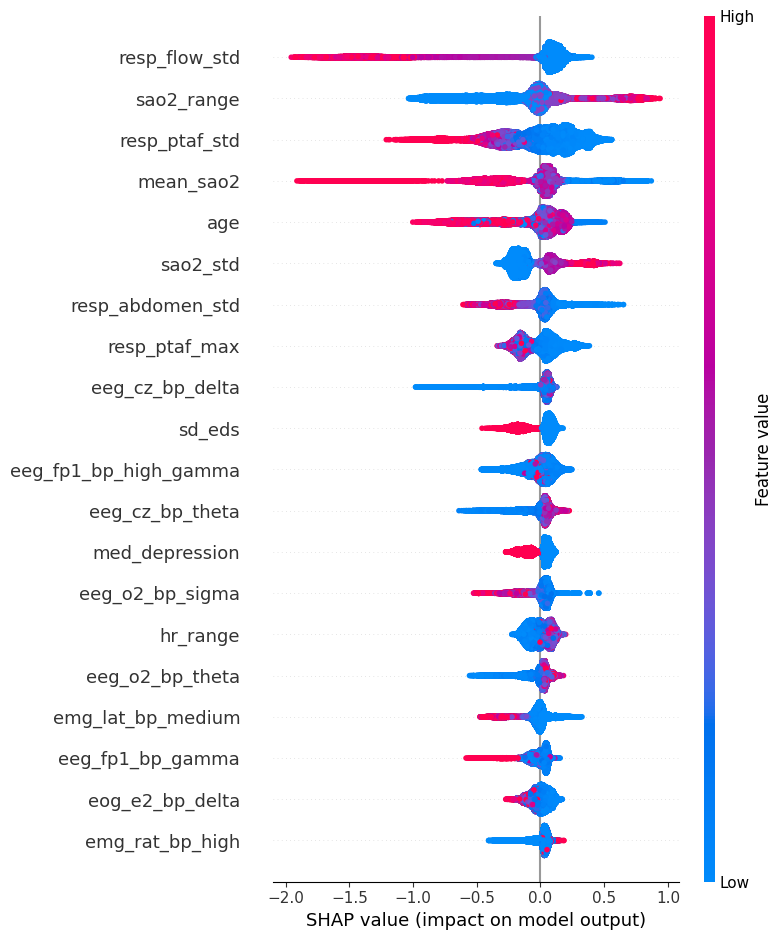

In [17]:
import shap

# Set base score explicitly to avoid the parsing issue
model_xgb.get_booster().set_param({'base_score': 0.5})

explainer = shap.TreeExplainer(model_xgb.get_booster())
shap_values = explainer.shap_values(val_X)

shap.summary_plot(shap_values, val_X, max_display=20)

### LightGBM

In [18]:
neg = (train_y == 0).sum()
pos = (train_y == 1).sum()

model_lgb = LGBMClassifier(
    n_estimators=5000,
    max_depth=4,              # shallower trees, was 6
    learning_rate=0.02,       # slower learning
    scale_pos_weight=neg/pos,
    colsample_bytree=0.6,     # use fewer features per tree
    subsample=0.6,            # use fewer samples per tree
    min_child_samples=50,    # require more samples per leaf
    reg_alpha= 0.2,            # L1 regularization
    reg_lambda=1.0,           # L2 regularization
    num_leaves=31,            # limit tree complexity
    random_state=42,
    metric='average_precision'
)


model_lgb.fit(
    train_X, train_y,
    eval_set=[(val_X, val_y)],
    callbacks=[
        lgb.early_stopping(50, first_metric_only=True),  # only watch average_precision
        lgb.log_evaluation(25)
    ],
)

[LightGBM] [Info] Number of positive: 29857, number of negative: 221783
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030785 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 49515
[LightGBM] [Info] Number of data points in the train set: 251640, number of used features: 225
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.118650 -> initscore=-2.005280
[LightGBM] [Info] Start training from score -2.005280
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

LGBMClassifier(colsample_bytree=0.6, learning_rate=0.02, max_depth=4,
               metric='average_precision', min_child_samples=50,
               n_estimators=5000, random_state=42, reg_alpha=0.2,
               reg_lambda=1.0, scale_pos_weight=7.428174297484677,
               subsample=0.6)

In [19]:
# Get model evaluation metrics for the train set
print("LightGBM Model Evaluation on Train Set:")
metrics = evaluate_model(model_lgb, train_X, train_y)
print(f"AUC-ROC: {metrics['auc_roc']:.4f}")
print(f"AUC-PR: {metrics['auc_pr']:.4f}")
print(f"F1 Score: {metrics['f1']:.4f}")
print("Classification Report:")
print(metrics['classification_report'])

# Get model evaluation metrics for the validation set
print("LightGBM Model Evaluation on Validation Set:")
metrics = evaluate_model(model_lgb, val_X, val_y)
print(f"AUC-ROC: {metrics['auc_roc']:.4f}")
print(f"AUC-PR: {metrics['auc_pr']:.4f}")
print(f"F1 Score: {metrics['f1']:.4f}")
print("Classification Report:")
print(metrics['classification_report'])

LightGBM Model Evaluation on Train Set:


AUC-ROC: 0.9782
AUC-PR: 0.8595
F1 Score: 0.7089
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94    221783
           1       0.56      0.96      0.71     29857

    accuracy                           0.91    251640
   macro avg       0.78      0.93      0.83    251640
weighted avg       0.94      0.91      0.92    251640

LightGBM Model Evaluation on Validation Set:
AUC-ROC: 0.9121
AUC-PR: 0.6806
F1 Score: 0.5855
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.87      0.92     77815
           1       0.47      0.77      0.59     11465

    accuracy                           0.86     89280
   macro avg       0.72      0.82      0.75     89280
weighted avg       0.90      0.86      0.87     89280



In [33]:
import optuna
from sklearn.metrics import average_precision_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

USE_GPU = False  # ← flip to True if GPU available

neg = (train_y == 0).sum()
pos = (train_y == 1).sum()
spw = neg / pos

BASE_PARAMS = {
    "n_estimators": 5000,
    "scale_pos_weight": spw,
    "random_state": 42,
    "metric": "average_precision",
    "verbosity": -1,
    "n_jobs": 1,                          # avoid thread contention during parallel trials
    **({"device": "gpu"} if USE_GPU else {}),
}

FIT_CALLBACKS = [
    lgb.early_stopping(50, first_metric_only=True, verbose=False),
    lgb.log_evaluation(-1),
]


def objective(trial):
    params = BASE_PARAMS | {
        "learning_rate":      trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "max_depth":          trial.suggest_int("max_depth", 3, 7),
        "num_leaves":         trial.suggest_int("num_leaves", 15, 63),
        "min_child_samples":  trial.suggest_int("min_child_samples", 20, 100),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.3, 0.8),
        "subsample":          trial.suggest_float("subsample", 0.4, 0.9),
        "reg_alpha":          trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda":         trial.suggest_float("reg_lambda", 0.0, 4.0),
    }

    model = LGBMClassifier(**params)
    model.fit(
        train_X, train_y,
        eval_set=[(val_X, val_y)],
        callbacks=FIT_CALLBACKS,
    )

    val_proba = model.predict_proba(val_X)[:, 1]
    return average_precision_score(val_y, val_proba)


study = optuna.create_study(direction="maximize")
study.optimize(
    objective,
    n_trials=50,
    n_jobs=-1,              # ← parallel trials across CPU cores
    show_progress_bar=True,
)

print(f"\nBest val AUC-PR: {study.best_value:.4f}")
print(f"Best params:     {study.best_params}")

# --- Retrain best model, use val only for early stopping ---
best_model_params = BASE_PARAMS | study.best_params

model_lgb_tuned = LGBMClassifier(**best_model_params)
model_lgb_tuned.fit(
    train_X, train_y,
    eval_set=[(val_X, val_y)],
    callbacks=FIT_CALLBACKS,
)

print("\n--- Tuned model evaluation ---")
for split_name, X, y in [
    ("Train", train_X, train_y),
    ("Val",   val_X,   val_y),
]:
    m = evaluate_model(model_lgb_tuned, X, y)
    print(f"{split_name:5s}  AUC-ROC={m['auc_roc']:.4f}  AUC-PR={m['auc_pr']:.4f}  F1={m['f1']:.4f}")

Best trial: 42. Best value: 0.690588: 100%|██████████| 50/50 [03:09<00:00,  3.78s/it]



Best val AUC-PR: 0.6906
Best params:     {'learning_rate': 0.04467962833316857, 'max_depth': 7, 'num_leaves': 63, 'min_child_samples': 44, 'colsample_bytree': 0.3307248762330681, 'subsample': 0.4194287534559143, 'reg_alpha': 1.5929966563425828, 'reg_lambda': 3.7061371338108535}

--- Tuned model evaluation ---
Train  AUC-ROC=0.9879  AUC-PR=0.9102  F1=0.7643
Val    AUC-ROC=0.9145  AUC-PR=0.6906  F1=0.5996


/usr/local/lib/python3.10/dist-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


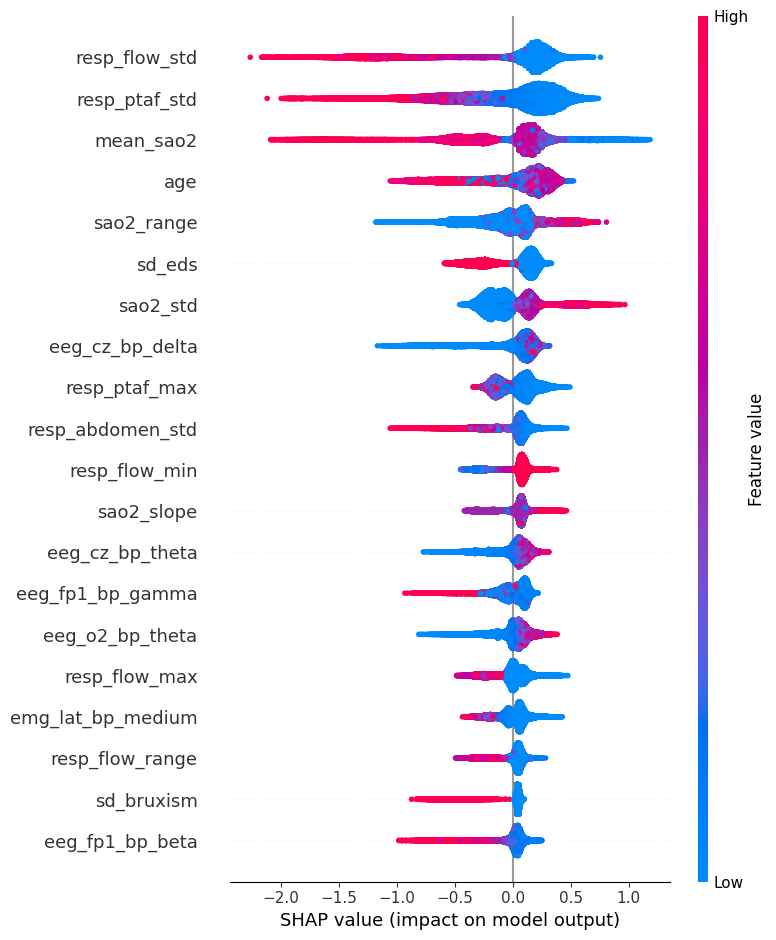

Dropped metadata columns from top features: ['mean_sao2', 'age', 'sd_eds', 'sd_bruxism']
Top SHAP features: ['resp_flow_std', 'resp_ptaf_std', 'sao2_range', 'sao2_std', 'eeg_cz_bp_delta', 'resp_ptaf_max', 'resp_abdomen_std', 'resp_flow_min', 'eeg_cz_bp_theta', 'sao2_slope', 'eeg_o2_bp_theta', 'eeg_fp1_bp_gamma', 'resp_flow_max', 'emg_lat_bp_medium', 'resp_flow_range', 'eeg_fp1_bp_high_gamma']


/usr/local/lib/python3.10/dist-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [34]:
explainer = shap.TreeExplainer(model_lgb_tuned)

# --- Validation set SHAP: for plotting/evaluation ---
val_shap_values = explainer.shap_values(val_X)
val_sv = val_shap_values[1] if isinstance(val_shap_values, list) else val_shap_values
shap.summary_plot(val_sv, val_X, max_display=20)

# --- Train set SHAP: for feature selection ---
# Using train set here to select features for the lagged model;
# val/test sets are kept unseen for downstream evaluation.
train_shap_values = explainer.shap_values(train_X)
train_sv = train_shap_values[1] if isinstance(train_shap_values, list) else train_shap_values

shap_importance = pd.Series(
    np.abs(train_sv).mean(axis=0),
    index=train_X.columns,
).sort_values(ascending=False)

# Filter out subject metadata columns from feature candidates
subject_metadata = pd.read_csv(Path(processed_dir) / 'participant_info.csv')
metadata_cols = set(subject_metadata.columns)

top_shap_features = [
    col for col in shap_importance.nlargest(20).index
    if col not in metadata_cols
]

dropped = [col for col in shap_importance.nlargest(20).index if col in metadata_cols]
if dropped:
    print(f"Dropped metadata columns from top features: {dropped}")

print(f"Top SHAP features: {top_shap_features}")

### Adding lag features for top SHAP features

In [35]:
lagged5_train_X, future0_train_y, lagged5_val_X, future0_val_y, lagged5_test_X, future0_test_y, left_out = create_batched_splits(
    parquet_files,
    batch_size=360,
    gap_size=6,
    top_features=top_shap_features,
    top_features_lag=5,
    target_type='apnea',
    target_future_steps=0,
    val_ratio=0.2,
    test_ratio=0.2,
    n_leave_out=5,
    random_seed=2542,
)

Subjects left out: ['S038', 'S003', 'S009', 'S068', 'S016']


In [36]:
neg = (future0_train_y == 0).sum()
pos = (future0_train_y == 1).sum()

model_lgb_lagged5_future0 = LGBMClassifier(
    n_estimators=5000,
    max_depth=4,
    learning_rate=0.02,
    scale_pos_weight=neg/pos,
    colsample_bytree=0.4,     # reduced from 0.6 — more features per tree increases collinearity noise
    subsample=0.6,
    min_child_samples=50,
    reg_alpha=0.5,            # increased from 0.2 — stronger L1 to prune redundant lag features
    reg_lambda=2.0,           # increased from 1.0 — stronger L2 for expanded feature space
    num_leaves=31,
    random_state=42,
    metric='average_precision'
)

model_lgb_lagged5_future0.fit(
    lagged5_train_X, future0_train_y,
    eval_set=[(lagged5_val_X, future0_val_y)],
    callbacks=[
        lgb.early_stopping(50, first_metric_only=True),
        lgb.log_evaluation(25)
    ],
)


Training until validation scores don't improve for 50 rounds
[25]	valid_0's average_precision: 0.533686
[50]	valid_0's average_precision: 0.548685
[75]	valid_0's average_precision: 0.563569
[100]	valid_0's average_precision: 0.577722
[125]	valid_0's average_precision: 0.589378
[150]	valid_0's average_precision: 0.598877
[175]	valid_0's average_precision: 0.606719
[200]	valid_0's average_precision: 0.6125
[225]	valid_0's average_precision: 0.619167
[250]	valid_0's average_precision: 0.625043
[275]	valid_0's average_precision: 0.632045
[300]	valid_0's average_precision: 0.638186
[325]	valid_0's average_precision: 0.643254
[350]	valid_0's average_precision: 0.647492
[375]	valid_0's average_precision: 0.651725
[400]	valid_0's average_precision: 0.655986
[425]	valid_0's average_precision: 0.659152
[450]	valid_0's average_precision: 0.662475
[475]	valid_0's average_precision: 0.664837
[500]	valid_0's average_precision: 0.667389
[525]	valid_0's average_precision: 0.669688
[550]	valid_0's aver

LGBMClassifier(colsample_bytree=0.4, learning_rate=0.02, max_depth=4,
               metric='average_precision', min_child_samples=50,
               n_estimators=5000, random_state=42, reg_alpha=0.5,
               reg_lambda=2.0, scale_pos_weight=7.414832649462512,
               subsample=0.6)

In [37]:
# Get model evaluation metrics for the train set
print("LightGBM Model Evaluation on Train Set:")
metrics = evaluate_model(model_lgb_lagged5_future0, lagged5_train_X, future0_train_y)
print(f"AUC-ROC: {metrics['auc_roc']:.4f}")
print(f"AUC-PR: {metrics['auc_pr']:.4f}")
print(f"F1 Score: {metrics['f1']:.4f}")
print("Classification Report:")
print(metrics['classification_report'])

# Get model evaluation metrics for the validation set
print("LightGBM Model Evaluation on Validation Set:")
metrics = evaluate_model(model_lgb_lagged5_future0, lagged5_val_X, future0_val_y)
print(f"AUC-ROC: {metrics['auc_roc']:.4f}")
print(f"AUC-PR: {metrics['auc_pr']:.4f}")
print(f"F1 Score: {metrics['f1']:.4f}")
print("Classification Report:")
print(metrics['classification_report'])

LightGBM Model Evaluation on Train Set:


AUC-ROC: 0.9741
AUC-PR: 0.8439
F1 Score: 0.6953
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94    218656
           1       0.55      0.94      0.70     29489

    accuracy                           0.90    248145
   macro avg       0.77      0.92      0.82    248145
weighted avg       0.94      0.90      0.91    248145

LightGBM Model Evaluation on Validation Set:
AUC-ROC: 0.9250
AUC-PR: 0.7129
F1 Score: 0.6087
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     76725
           1       0.49      0.80      0.61     11315

    accuracy                           0.87     88040
   macro avg       0.73      0.84      0.76     88040
weighted avg       0.91      0.87      0.88     88040



/usr/local/lib/python3.10/dist-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


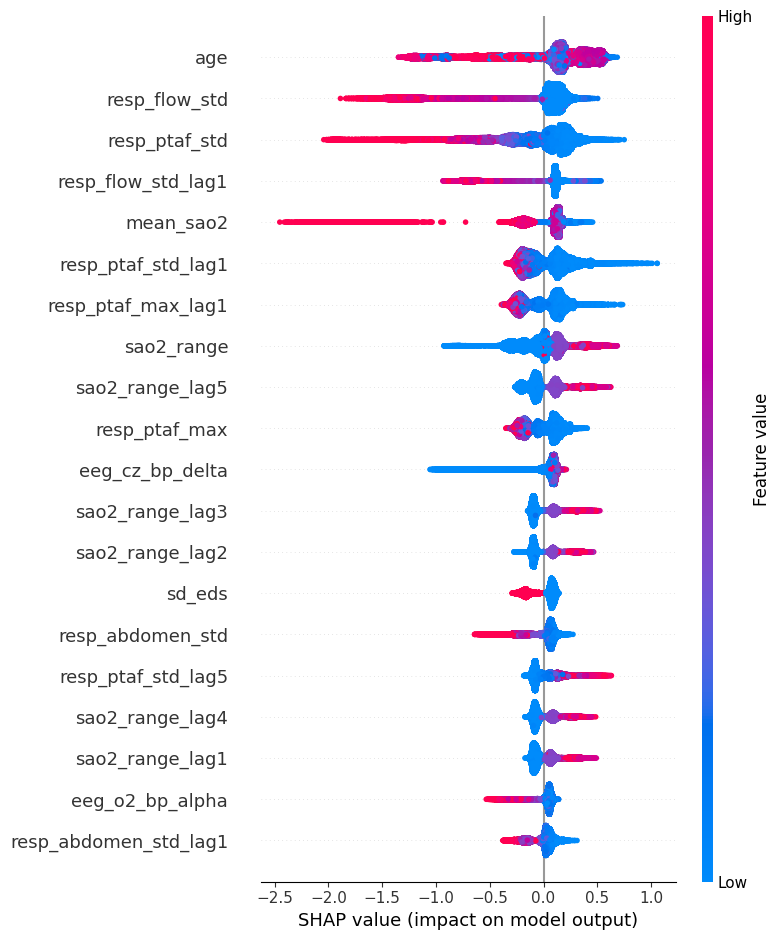

In [38]:
explainer = shap.TreeExplainer(model_lgb_lagged5_future0)
shap_values = explainer.shap_values(lagged5_val_X)

shap.summary_plot(shap_values, lagged5_val_X, max_display=20)

Hyperparameter tuning

In [39]:
import optuna
from sklearn.metrics import average_precision_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

USE_GPU = False  # ← flip to True if GPU available

neg = (future0_train_y == 0).sum()
pos = (future0_train_y == 1).sum()
spw = neg / pos

BASE_PARAMS = {
    "n_estimators": 5000,
    "scale_pos_weight": spw,
    "random_state": 42,
    "metric": "average_precision",
    "verbosity": -1,
    "n_jobs": 1,                          # avoid thread contention during parallel trials
    **({"device": "gpu"} if USE_GPU else {}),
}

FIT_CALLBACKS = [
    lgb.early_stopping(50, first_metric_only=True, verbose=False),
    lgb.log_evaluation(-1),
]


def objective(trial):
    params = BASE_PARAMS | {
        "learning_rate":      trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "max_depth":          trial.suggest_int("max_depth", 3, 7),
        "num_leaves":         trial.suggest_int("num_leaves", 15, 63),
        "min_child_samples":  trial.suggest_int("min_child_samples", 20, 100),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.3, 0.8),
        "subsample":          trial.suggest_float("subsample", 0.4, 0.9),
        "reg_alpha":          trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda":         trial.suggest_float("reg_lambda", 0.0, 4.0),
    }

    model = LGBMClassifier(**params)
    model.fit(
        lagged5_train_X, future0_train_y,
        eval_set=[(lagged5_val_X, future0_val_y)],
        callbacks=FIT_CALLBACKS,
    )

    val_proba = model.predict_proba(lagged5_val_X)[:, 1]
    return average_precision_score(future0_val_y, val_proba)


study = optuna.create_study(direction="maximize")
study.optimize(
    objective,
    n_trials=50,
    n_jobs=-1,              # ← parallel trials across CPU cores
    show_progress_bar=True,
)

print(f"\nBest val AUC-PR: {study.best_value:.4f}")
print(f"Best params:     {study.best_params}")

# --- Retrain best model, use val only for early stopping ---
best_model_params = BASE_PARAMS | study.best_params

model_lgb_lagged5_future0_tuned = LGBMClassifier(**best_model_params)
model_lgb_lagged5_future0_tuned.fit(
    lagged5_train_X, future0_train_y,
    eval_set=[(lagged5_val_X, future0_val_y)],
    callbacks=FIT_CALLBACKS,
)

print("\n--- Tuned model evaluation ---")
for split_name, X, y in [
    ("Train", lagged5_train_X, future0_train_y),
    ("Val",   lagged5_val_X,   future0_val_y),
]:
    m = evaluate_model(model_lgb_lagged5_future0_tuned, X, y)
    print(f"{split_name:5s}  AUC-ROC={m['auc_roc']:.4f}  AUC-PR={m['auc_pr']:.4f}  F1={m['f1']:.4f}")

Best trial: 11. Best value: 0.724321: 100%|██████████| 50/50 [02:48<00:00,  3.37s/it]



Best val AUC-PR: 0.7243
Best params:     {'learning_rate': 0.07597697739113214, 'max_depth': 7, 'num_leaves': 40, 'min_child_samples': 83, 'colsample_bytree': 0.5044557862202073, 'subsample': 0.6659847676637868, 'reg_alpha': 1.864280995720721, 'reg_lambda': 0.32782701390785407}

--- Tuned model evaluation ---
Train  AUC-ROC=0.9888  AUC-PR=0.9166  F1=0.7766
Val    AUC-ROC=0.9270  AUC-PR=0.7243  F1=0.6335
